# Difference-in-Differences (DiD) Template

This notebook demonstrates how to use the improved `did.py` module for Difference-in-Differences analysis, including Two-Way Fixed Effects (TWFE), Event Studies, and **Advanced Techniques** like Stacked DiD and Sensitivity Analysis.

In [6]:
import sys
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Add src to path
sys.path.append(os.path.abspath('../src'))

# Force reload of external modules if they change
%load_ext autoreload
%autoreload 2

from did import (
    simulate_did_panel, did_twfe, event_study, visualize_trends, visualize_event_study,
    simulate_staggered_did, run_stacked_did, run_placebo_test, run_leave_one_out_sensitivity, visualize_sensitivity,
    synthetic_control, visualize_synthetic_control, wild_cluster_bootstrap, bacon_decomposition
)

%matplotlib inline
plt.style.use('ggplot')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Classic DiD & Event Study

We start with a standard setup where treatment starts at the same time for all treated units.

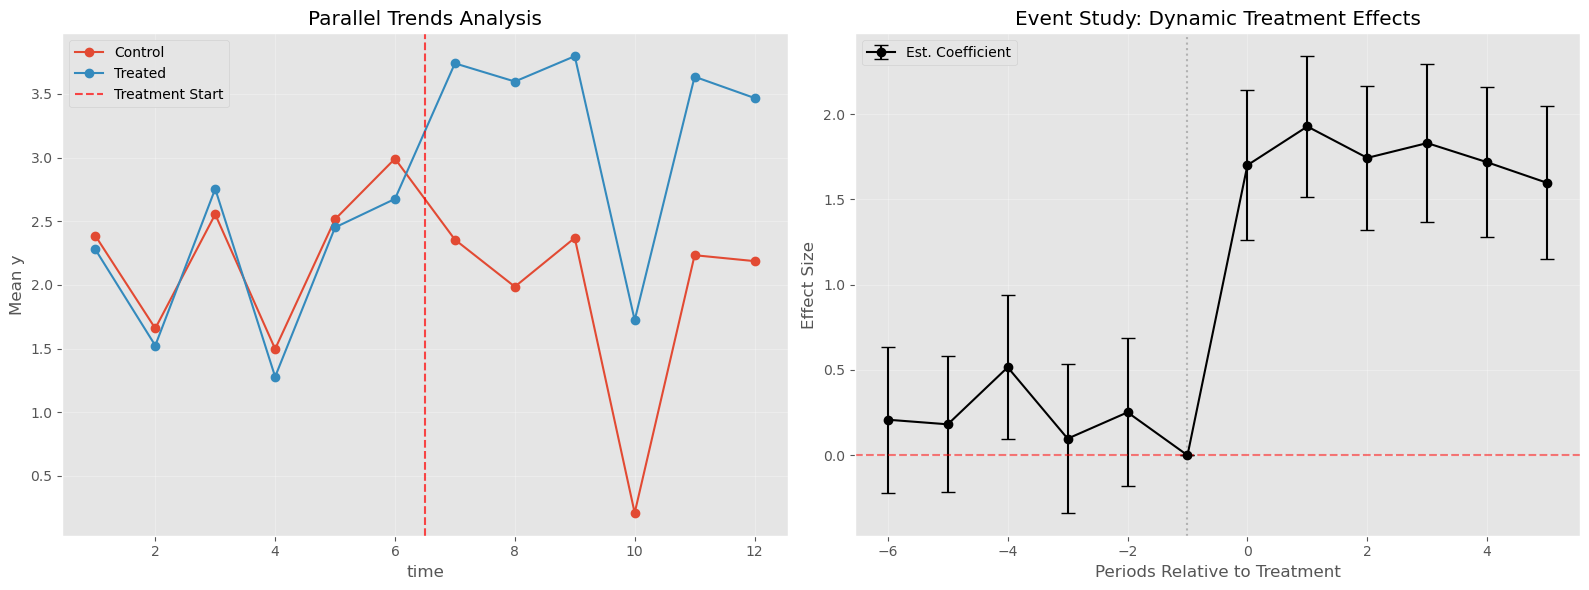

In [7]:
df = simulate_did_panel(n_units=200, n_periods=12, treat_start=7, effect=1.5, seed=42)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
visualize_trends(df, y='y', unit='unit', time='time', treated='treated', treat_start=7, ax=ax1)
res_event = event_study(df, y='y', unit='unit', time='time', treated='treated', treat_start=7, cluster='unit')
visualize_event_study(res_event, ax=ax2)
plt.tight_layout()
plt.show()

## 2. Advanced: Staggered Treatment Timing

When units are treated at different times, standard TWFE can be biased. Here we use **Stacked DiD** to avoid these issues.

In [8]:
# Simulate staggered treatment
df_staggered = simulate_staggered_did(n_units=200, n_periods=15, treat_share=0.5, min_treat_start=5, max_treat_start=10, effect=1.5)
    
# Run Stacked DiD
res_stacked = run_stacked_did(df_staggered, y='y', unit='unit', time='time', treat_start_col='treat_start', cluster='unit')

print(f"\nStacked DiD Estimated Effect: {res_stacked.params['did']:.4f}")


Stacked DiD Estimated Effect: 1.4945


## 3. Sensitivity Analysis: Placebo & Leave-One-Out

Check robustness against spurious correlations and outliers.

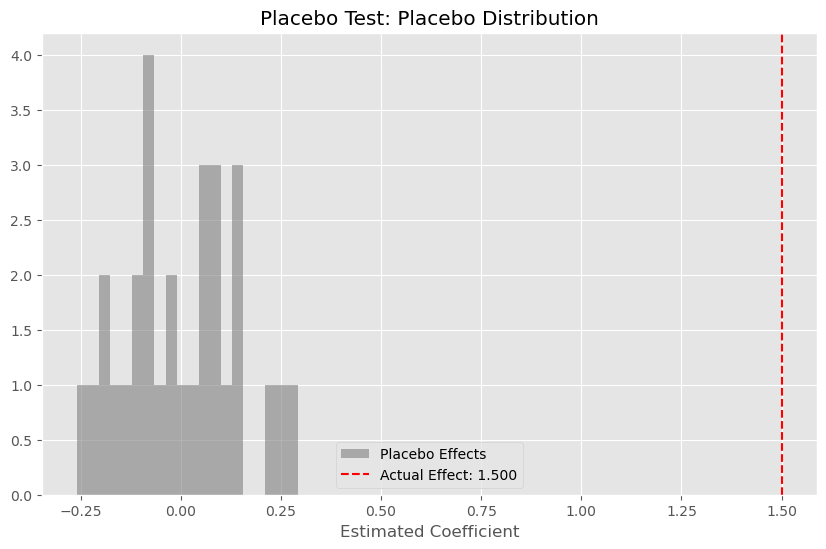

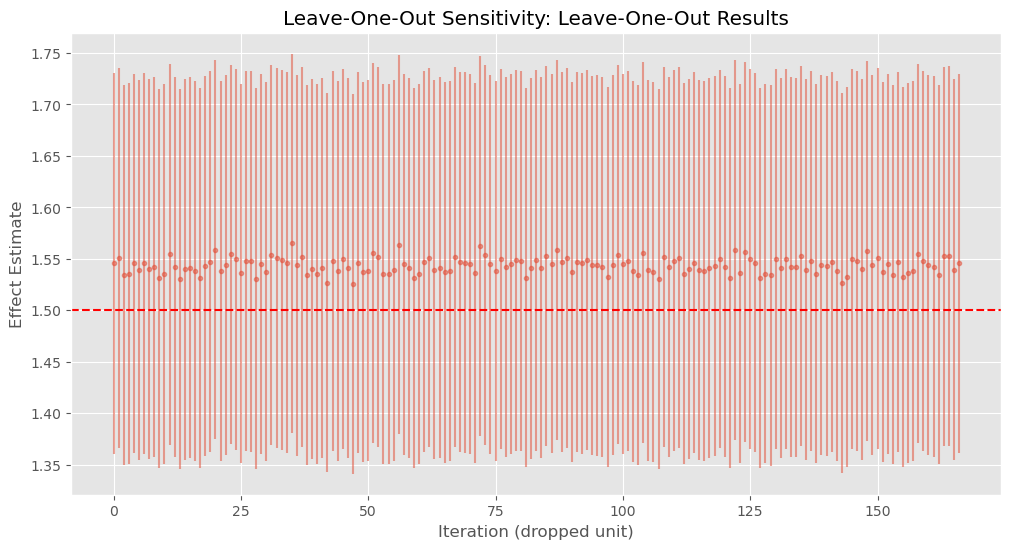

In [9]:
# Placebo Test
placebos = run_placebo_test(df, y='y', unit='unit', time='time', treated='treated', post='post', n_iterations=30)
visualize_sensitivity(placebo_effects=placebos, true_effect=1.5, title="Placebo Test")
plt.show()

# Leave-One-Out (Subset for speed)
loo_res = run_leave_one_out_sensitivity(df.iloc[:2000], y='y', unit='unit', time='time', treated='treated', post='post')
visualize_sensitivity(loo_results=loo_res, true_effect=1.5, title="Leave-One-Out Sensitivity")
plt.show()

## 4. Diagnostics & Robustness

### Synthetic Control Method
Best when investigating a single treated unit (e.g., a specific country or region).

Analyzing specific treated unit: 6 (Treatment starts at t=7)


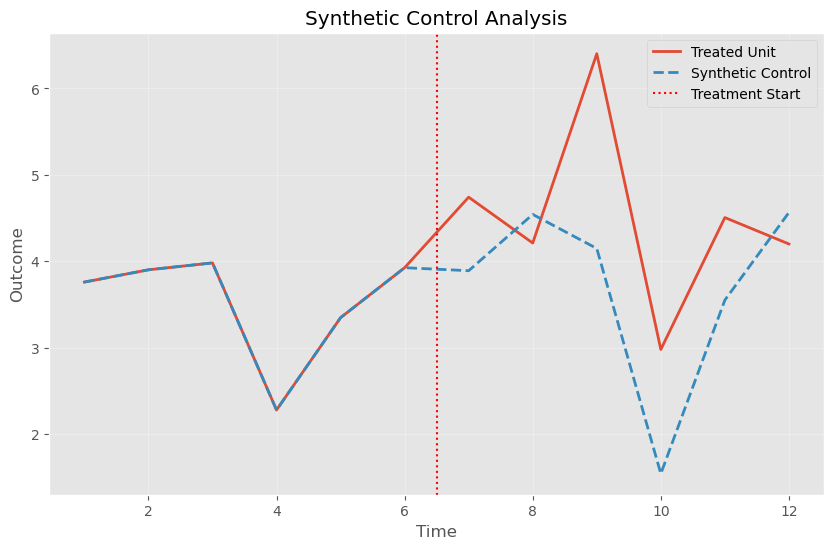

In [10]:
# Select one treated unit to analyze individually
treated_unit = df[df['treated'] == 1]['unit'].iloc[0]
treat_start = 7

print(f"Analyzing specific treated unit: {treated_unit} (Treatment starts at t={treat_start})")

res_sc, weights = synthetic_control(
    df, y='y', unit='unit', time='time', 
    treated_unit=treated_unit, treat_start=treat_start
)

visualize_synthetic_control(res_sc, treat_start)
plt.show()

### Wild Cluster Bootstrap
Provides robust p-values when the number of clusters is small (< 30).

In [11]:
# Fit standard model first
model = did_twfe(df, y='y', unit='unit', time='time', treated='treated', post='post', cluster='unit')

print(f"Standard OLS p-value: {model.pvalues['did']:.4f}")

# Run Wild Bootstrap (slower but robust)
boot_res = wild_cluster_bootstrap(model, cluster_var='unit', n_boot=200)
print(f"Wild Bootstrap SE: {boot_res['se_boot']:.4f}")
print(f"Wild Bootstrap CI: [{boot_res['ci_lower']:.4f}, {boot_res['ci_upper']:.4f}]")

Standard OLS p-value: 0.0000
Wild Bootstrap SE: 0.0900
Wild Bootstrap CI: [1.3877, 1.7369]


### Goodman-Bacon Decomposition
Breaks down the TWFE coefficient into weighted 2x2 comparisons to identify what drives your esimate.

In [12]:
print("Decomposing Staggered DiD Estimate...")
# Note: Needs a column with treatment start time (inf for untreated)
# We use the staggered dataset here
bacon_res = bacon_decomposition(
    df_staggered, y='y', unit='unit', time='time', 
    treated='treated', treat_start_col='treat_start'
)

if not bacon_res.empty:
    print("Top 5 Comparisons by Weight:")
    print(bacon_res.sort_values('weight', ascending=False).head())
else:
    print("No valid 2x2 comparisons found (check if multiple treatment timings exist).")

Decomposing Staggered DiD Estimate...
Top 5 Comparisons by Weight:
               type  treated_group control_group  weight      beta
4  Vs Never Treated            9.0         Never    1815  1.408404
2  Vs Never Treated            7.0         Never    1785  1.561354
0  Vs Never Treated            5.0         Never    1740  1.499146
3  Vs Never Treated            8.0         Never    1710  1.555222
1  Vs Never Treated            6.0         Never    1650  1.409695
